In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')


In [3]:
#  CARICAMENTO E PRIMA ESPLORAZIONE
# -----------------------------------------------------------------------------
df = pd.read_csv('dataset_olimpiadi_indicatori_ita.csv')

print(f"Shape originale: {df.shape[0]:,} righe × {df.shape[1]} colonne")
print(f"Duplicati: {df.duplicated().sum()}")
print(f"\nColonne ({df.shape[1]}):")
for col in df.columns:
    print(f"  {col}")


Shape originale: 3,368 righe × 40 colonne
Duplicati: 0

Colonne (40):
  Edizione_Olimpiadi
  ID_Edizione
  Anno
  Nazione
  Codice_NOC
  Medaglie_Oro
  Medaglie_Argento
  Medaglie_Bronzo
  Totale_Medaglie
  Paese_Ospitante
  Citta_Ospitante
  Precipitazioni_Medie_mm
  Superficie_Totale_km2
  Investimenti_Diretti_Esteri_perc_PIL
  Densita_Popolazione
  Inflazione_Prezzi_Consumo
  Spesa_Militare_Valuta_Locale
  Spesa_Militare_perc_PIL
  Spesa_Pubblica_Consumi_USD
  Spesa_Nazionale_Lorda_Valuta_Locale
  Interscambio_Commerciale_perc_PIL
  Valore_Aggiunto_Industria_perc_PIL
  Valore_Aggiunto_Servizi_Valuta_Locale
  Valore_Aggiunto_Servizi_perc_PIL
  Inflazione_Deflatore_PIL
  PIL_Assoluto_USD
  PIL_Valuta_Locale
  Crescita_PIL_perc_annua
  PIL_Pro_Capite_USD
  RNL_Valuta_Locale
  RNL_Pro_Capite_USD
  Iscrizioni_Scuola_Primaria_perc
  Tasso_Mortalita_Neonatale
  Tasso_Mortalita_Infantile
  Aspettativa_di_Vita
  Popolazione_Eta_Lavorativa_perc
  Crescita_Demografica_perc
  Popolazione_Totale

In [4]:
#  RIMOZIONE DUPLICATI
# -----------------------------------------------------------------------------
n_before = len(df)
df = df.drop_duplicates()
n_after = len(df)
print(f"Duplicati rimossi: {n_before - n_after}")
print(f"Righe rimaste: {n_after:,}")


Duplicati rimossi: 0
Righe rimaste: 3,368


In [5]:
# -----------------------------------------------------------------------------
# Il dataset ha 40 colonne già rinominate in italiano.
# Teniamo solo quelle rilevanti per l'analisi e le rinominiamo in inglese
# per coerenza con il resto della pipeline.
#
# Colonne escluse e perché:
#   - PIL_Valuta_Locale / RNL_Valuta_Locale        → redundant with USD versions
#   - RNL_Pro_Capite_USD                           → redundant with GDP
#   - Spesa_Pubblica_Consumi_USD                   → gov consumption, too many nulls (41%)
#   - Spesa_Militare_*                             → military spending, not relevant
#   - Valore_Aggiunto_Servizi_*                    → too many nulls (43%)
#   - Spesa_Nazionale_Lorda_Valuta_Locale          → gross national income in local currency
#   - Interscambio_Commerciale_perc_PIL            → trade openness, not relevant
#   - Valore_Aggiunto_Industria_perc_PIL           → industry value added, not relevant
#   - Inflazione_Deflatore_PIL                     → GDP deflator, not relevant
#   - Crescita_PIL_perc_annua                      → real GDP growth, too many nulls
#   - Inflazione_Prezzi_Consumo                    → inflation, 39% nulls
#   - Investimenti_Diretti_Esteri_perc_PIL         → FDI, 36% nulls
#   - Tasso_Mortalita_Neonatale                    → overlaps with infant_mortality
#   - Precipitazioni_Medie_mm                      → not relevant
#   - Superficie_Totale_km2                        → not relevant
#   - Popolazione_Urbana                           → absolute value, use % instead
#   - Popolazione_Eta_Lavorativa_perc              → not relevant
#   - Crescita_Demografica_perc                    → not relevant
#   - ID_Edizione                                  → numeric id, not needed


In [6]:
RENAME_MAP = {
    # Identificatori e medaglie
    'Edizione_Olimpiadi':          'edition',
    'Anno':                        'year',
    'Nazione':                     'country',
    'Codice_NOC':                  'noc',
    'Medaglie_Oro':                'gold',
    'Medaglie_Argento':            'silver',
    'Medaglie_Bronzo':             'bronze',
    'Totale_Medaglie':             'total_medals',
    'Paese_Ospitante':             'host_country_code',
    'Citta_Ospitante':             'host_city',

    # Indicatori socioeconomici selezionati
    'PIL_Pro_Capite_USD':          'gdp_per_capita',          # PIL pro capite (USD correnti)
    'Aspettativa_di_Vita':         'life_expectancy',         # Aspettativa di vita alla nascita
    'Tasso_Urbanizzazione_perc':   'urbanization_pct',        # Popolazione urbana (%)
    'Popolazione_Totale':          'population',              # Popolazione totale
    'Densita_Popolazione':         'pop_density',             # Densità di popolazione
    'Iscrizioni_Scuola_Primaria_perc': 'primary_school_enrollment',  # Iscrizione scuola primaria (%)
    'Tasso_Mortalita_Infantile':   'infant_mortality',        # Mortalità infantile (per 1000 nati)
    'PIL_Assoluto_USD':            'gdp_total',               # PIL totale (USD) — utile per normalizzare
}


In [7]:
# Selezioniamo e rinominiamo
df = df[list(RENAME_MAP.keys())].rename(columns=RENAME_MAP)

print(f"Colonne dopo selezione: {df.shape[1]}")
print(df.columns.tolist())

Colonne dopo selezione: 18
['edition', 'year', 'country', 'noc', 'gold', 'silver', 'bronze', 'total_medals', 'host_country_code', 'host_city', 'gdp_per_capita', 'life_expectancy', 'urbanization_pct', 'population', 'pop_density', 'primary_school_enrollment', 'infant_mortality', 'gdp_total']


In [8]:
#  CONTROLLO E CORREZIONE DEI TIPI
# -----------------------------------------------------------------------------
print("=== TIPI PRIMA DELLA CORREZIONE ===")
print(df.dtypes)

# 'year' deve essere intero
df['year'] = pd.to_numeric(df['year'], errors='coerce').astype('Int64')

# Colonne numeriche — forziamo float per sicurezza
numeric_cols = [
    'gold', 'silver', 'bronze', 'total_medals',
    'gdp_per_capita', 'life_expectancy', 'urbanization_pct',
    'population', 'pop_density', 'primary_school_enrollment',
    'infant_mortality', 'gdp_total'
]
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Colonne testuali — strip spazi
text_cols = ['edition', 'country', 'noc', 'host_country_code', 'host_city']
for col in text_cols:
    df[col] = df[col].astype(str).str.strip()

print("\n=== TIPI DOPO LA CORREZIONE ===")
print(df.dtypes)

=== TIPI PRIMA DELLA CORREZIONE ===
edition                       object
year                         float64
country                       object
noc                           object
gold                         float64
silver                       float64
bronze                       float64
total_medals                 float64
host_country_code             object
host_city                     object
gdp_per_capita               float64
life_expectancy              float64
urbanization_pct             float64
population                   float64
pop_density                  float64
primary_school_enrollment    float64
infant_mortality             float64
gdp_total                    float64
dtype: object

=== TIPI DOPO LA CORREZIONE ===
edition                       object
year                           Int64
country                       object
noc                           object
gold                         float64
silver                       float64
bronze                       

In [9]:
#  CONTROLLO VALORI ANOMALI (OUTLIER)
# -----------------------------------------------------------------------------
print("=== STATISTICHE DESCRITTIVE ===")
print(df[numeric_cols].describe().round(2).to_string())

=== STATISTICHE DESCRITTIVE ===
          gold   silver   bronze  total_medals  gdp_per_capita  life_expectancy  urbanization_pct    population  pop_density  primary_school_enrollment  infant_mortality     gdp_total
count  3368.00  3368.00  3368.00       3368.00         2628.00          3083.00           3090.00  3.083000e+03      2810.00                    1946.00           2697.00  2.628000e+03
mean      1.12     1.12     1.26          3.50         8161.83            64.31             50.38  2.564568e+07       339.05                      95.64             51.89  1.656762e+11
std       4.83     4.11     4.12         12.68        16666.70            11.28             25.29  1.046048e+08      1672.87                      23.63             46.49  9.017922e+11
min       0.00     0.00     0.00          0.00           15.20            18.89              1.97  4.896500e+03         0.10                       3.12              1.60  2.651473e+06
25%       0.00     0.00     0.00          0.00  

In [10]:
# Medaglie non possono essere negative
neg_medals = (df[['gold', 'silver', 'bronze', 'total_medals']] < 0).any(axis=1).sum()
print(f"\nRighe con medaglie negative: {neg_medals}")


Righe con medaglie negative: 0


In [11]:
# Verifica coerenza: total_medals deve essere = gold + silver + bronze
df['medals_check'] = df['gold'] + df['silver'] + df['bronze']
mismatch = (df['medals_check'] != df['total_medals']).sum()
print(f"Righe dove total ≠ gold+silver+bronze: {mismatch}")
df = df.drop(columns=['medals_check'])

Righe dove total ≠ gold+silver+bronze: 0


In [12]:
# Valori impossibili per gli indicatori
print("\nRange aspettativa di vita:")
print(f"  Min: {df['life_expectancy'].min():.1f} — Max: {df['life_expectancy'].max():.1f}")
print("Range urbanizzazione (%):")
print(f"  Min: {df['urbanization_pct'].min():.1f} — Max: {df['urbanization_pct'].max():.1f}")
print("Range mortalità infantile:")
print(f"  Min: {df['infant_mortality'].min():.1f} — Max: {df['infant_mortality'].max():.1f}")


Range aspettativa di vita:
  Min: 18.9 — Max: 85.9
Range urbanizzazione (%):
  Min: 2.0 — Max: 100.0
Range mortalità infantile:
  Min: 1.6 — Max: 271.9


In [13]:
# Sostituiamo con NaN i valori fuori range logico
df.loc[df['life_expectancy'] < 20,  'life_expectancy']  = np.nan
df.loc[df['life_expectancy'] > 100, 'life_expectancy']  = np.nan
df.loc[df['urbanization_pct'] < 0,  'urbanization_pct'] = np.nan
df.loc[df['urbanization_pct'] > 100,'urbanization_pct'] = np.nan
df.loc[df['infant_mortality'] < 0,  'infant_mortality'] = np.nan

In [14]:
#  GESTIONE DEI VALORI NULLI — REPORT E STRATEGIA
# -----------------------------------------------------------------------------
null_pct = (df.isnull().sum() / len(df) * 100).round(1).sort_values(ascending=False)
print("=== NULL PER COLONNA (%) ===")
print(null_pct[null_pct > 0].to_string())

=== NULL PER COLONNA (%) ===
primary_school_enrollment    42.2
gdp_per_capita               22.0
gdp_total                    22.0
infant_mortality             19.9
pop_density                  16.6
life_expectancy               8.5
population                    8.5
urbanization_pct              8.3


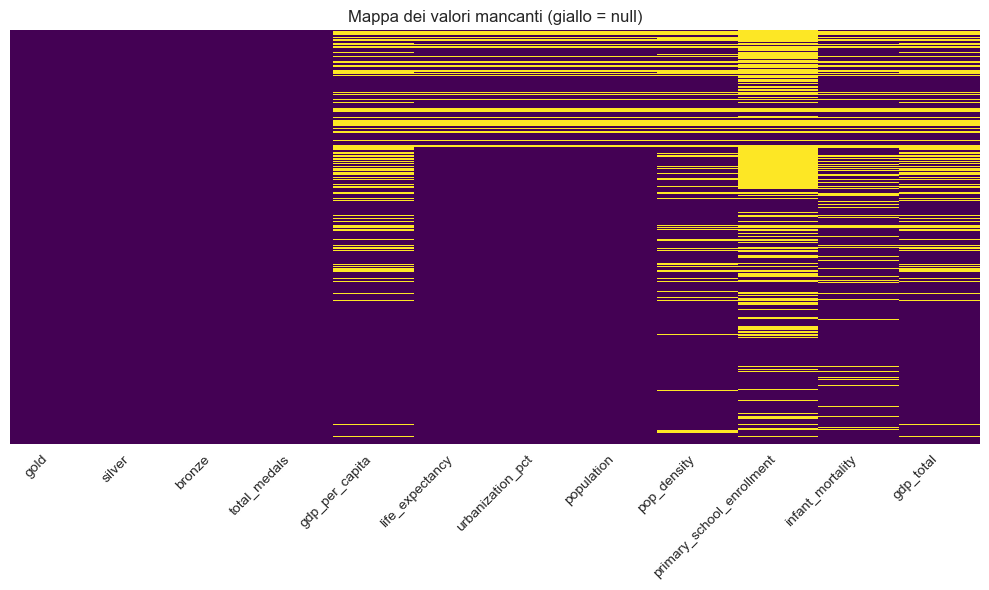

In [15]:
# Visualizzazione della mappa dei null
fig, ax = plt.subplots(figsize=(10, 6))
null_data = df[numeric_cols].isnull()
sns.heatmap(null_data, yticklabels=False, cbar=False, cmap='viridis', ax=ax)
ax.set_title('Mappa dei valori mancanti (giallo = null)', fontsize=12)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
plt.tight_layout()
plt.savefig('missing_values_map.png', dpi=150, bbox_inches='tight')
plt.show()

In [16]:
# STRATEGIA SCELTA: teniamo tutti i null (li gestiamo nell'analisi)
# Non droppiamo righe né imputiamo qui — lo faremo nel notebook di clustering
# con SimpleImputer solo sulle variabili usate per il clustering.
print("\nStrategia: null mantenuti, verranno gestiti nel clustering.")


Strategia: null mantenuti, verranno gestiti nel clustering.


In [17]:
# STRATEGIA SCELTA: teniamo tutti i null (li gestiamo nell'analisi)
# Non droppiamo righe né imputiamo qui — lo faremo nel notebook di clustering
# con SimpleImputer solo sulle variabili usate per il clustering.
print("\nStrategia: null mantenuti, verranno gestiti nel clustering.")


#  CREAZIONE VARIABILI DERIVATE
# -----------------------------------------------------------------------------
# Medaglie normalizzate per popolazione (per milione di abitanti)
# Essenziale per confrontare paesi di dimensioni diverse
df['medals_per_million'] = (
    df['total_medals'] / df['population'] * 1_000_000
).round(4)

df['gold_per_million'] = (
    df['gold'] / df['population'] * 1_000_000
).round(4)

# Medaglie normalizzate per PIL totale (per miliardo di USD)
# Cattura l'efficienza sportiva rispetto alla ricchezza del paese
df['medals_per_gdp_bn'] = (
    df['total_medals'] / (df['gdp_total'] / 1e9)
).round(4)

# Flag binario: il paese ha vinto almeno una medaglia in quell'edizione
df['won_medal'] = (df['total_medals'] > 0).astype(int)

# Placeholder per HDI (da aggiungere in seguito se si scarica il file UNDP)
df['hdi'] = np.nan

print("Variabili derivate create:")
print("  medals_per_million, gold_per_million, medals_per_gdp_bn, won_medal, hdi")



Strategia: null mantenuti, verranno gestiti nel clustering.
Variabili derivate create:
  medals_per_million, gold_per_million, medals_per_gdp_bn, won_medal, hdi


In [18]:
#  VERIFICA FINALE E REPORT
# -----------------------------------------------------------------------------
print("=" * 50)
print("REPORT FINALE DATASET PULITO")
print("=" * 50)
print(f"Righe:    {df.shape[0]:,}")
print(f"Colonne:  {df.shape[1]}")
print(f"Anni:     {df['year'].min()} – {df['year'].max()}")
print(f"Paesi:    {df['country'].nunique()}")
print(f"Edizioni: {df['year'].nunique()}")
print()

null_final = (df.isnull().sum() / len(df) * 100).round(1)
print("Null residui per colonna (%):")
print(null_final[null_final > 0].sort_values(ascending=False).to_string())

print()
print("Anteprima:")
print(df.head(3).to_string())

REPORT FINALE DATASET PULITO
Righe:    3,368
Colonne:  23
Anni:     1964 – 2020
Paesi:    232
Edizioni: 15

Null residui per colonna (%):
hdi                          100.0
primary_school_enrollment     42.2
gdp_per_capita                22.0
medals_per_gdp_bn             22.0
gdp_total                     22.0
infant_mortality              19.9
pop_density                   16.6
life_expectancy                8.5
gold_per_million               8.5
population                     8.5
medals_per_million             8.5
urbanization_pct               8.3

Anteprima:
                edition  year        country  noc  gold  silver  bronze  total_medals host_country_code host_city  gdp_per_capita  life_expectancy  urbanization_pct   population  pop_density  primary_school_enrollment  infant_mortality     gdp_total  medals_per_million  gold_per_million  medals_per_gdp_bn  won_medal  hdi
0  1964 Summer Olympics  1964  United States  USA  36.0    26.0    28.0          90.0               JPN    

In [19]:
# SALVATAGGIO
# -----------------------------------------------------------------------------
df.to_csv('olympics_clean.csv', index=False)
print("\n✓ Salvato: olympics_clean.csv")
print("  → questo file è l'input per clustering_olimpiadi.py")


✓ Salvato: olympics_clean.csv
  → questo file è l'input per clustering_olimpiadi.py
